# 04.1 — Hypothesis 1

## Effect of emotional condition on working-memory performance

### Hypothesis

Positive, negative, and neutral emotional conditions differentially
affect working-memory performance.

### Primary outcomes

1. Trial-level response accuracy.
2. Reaction time for valid correct-response trials.

### Primary predictor

Emotional condition:

- Neutral
- Positive
- Negative

### Analytical strategy

Accuracy is analyzed using a binomial repeated-measures model.

Reaction time is analyzed using a linear mixed-effects model with
participant-specific random effects.

This notebook contains the confirmatory analysis for Hypothesis 1.

# Imports

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from src import config as cfg

from src.utils import (
    initialize_project,
)

from src.models import (
    fit_mixed_model,
    fit_binary_gee,
)

initialize_project()

In [2]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Data

In [3]:
analysis = pd.read_csv(
    cfg.ANALYSIS_DATASET_FILE,
    low_memory=False,
)

In [4]:
from src.preprocessing import (
    derive_emotion_condition
)

analysis = derive_emotion_condition(analysis)
analysis.to_csv(
    cfg.ANALYSIS_DATASET_FILE,
    index=False
)

In [5]:
analysis[
    "emotion_condition"
].value_counts(
    dropna=False
)

emotion_condition
Neutral     5940
Negative    5940
Positive    5940
Name: count, dtype: int64

# Audit

In [6]:
condition_participants = (
    analysis.groupby(
        "emotion_condition"
    )[
        "participant_id"
    ]
    .nunique()
)

condition_participants

emotion_condition
Negative    22
Neutral     23
Positive    22
Name: participant_id, dtype: int64

In [7]:
condition_trials = (
    analysis[
        "emotion_condition"
    ]
    .value_counts()
)

condition_trials

emotion_condition
Neutral     5940
Negative    5940
Positive    5940
Name: count, dtype: int64

# Describe accuracy

In [8]:
accuracy_summary = (
    analysis
    .groupby(
        "emotion_condition"
    )
    .agg(
        participants=(
            "participant_id",
            "nunique",
        ),
        trials=(
            "accuracy",
            "size",
        ),
        correct=(
            "accuracy",
            "sum",
        ),
        accuracy=(
            "accuracy",
            "mean",
        ),
    )
    .reset_index()
)

accuracy_summary

,emotion_condition,participants,trials,correct,accuracy
0,Negative,22,5940,4978,0.838047
1,Neutral,23,5940,5049,0.850000
2,Positive,22,5940,5055,0.851010


# Base participant x condition

In [9]:
participant_accuracy = (
    analysis
    .groupby(
        [
            "participant_id",
            "emotion_condition",
        ]
    )
    ["accuracy"]
    .mean()
    .reset_index()
)

In [10]:
participant_accuracy.groupby(
    "emotion_condition"
)[
    "accuracy"
].agg(
    [
        "count",
        "mean",
        "std",
        "median",
    ]
)

,count,mean,std,median
emotion_condition,,,,
Negative,22,0.838047,0.059206,0.850000
Neutral,23,0.846699,0.053970,0.862963
Positive,22,0.851010,0.056331,0.855556


# Plot accuracy

In [11]:
accuracy_plot = (
    participant_accuracy
    .groupby(
        "emotion_condition"
    )
    ["accuracy"]
    .agg(
        [
            "mean",
            "sem",
        ]
    )
    .reset_index()
)

In [12]:
order = [
    "Neutral",
    "Positive",
    "Negative",
]

accuracy_plot = (
    accuracy_plot
    .set_index(
        "emotion_condition"
    )
    .loc[order]
    .reset_index()
)

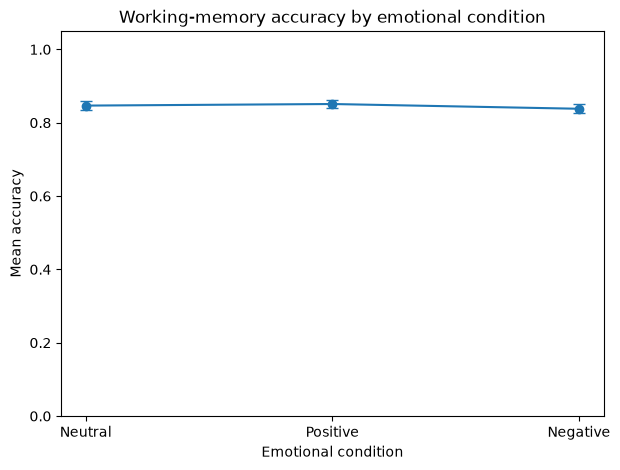

In [13]:
fig, ax = plt.subplots(
    figsize=(7, 5)
)

ax.errorbar(
    accuracy_plot[
        "emotion_condition"
    ],
    accuracy_plot[
        "mean"
    ],
    yerr=accuracy_plot[
        "sem"
    ],
    marker="o",
    capsize=4,
)

ax.set_ylabel(
    "Mean accuracy"
)

ax.set_xlabel(
    "Emotional condition"
)

ax.set_ylim(
    0,
    1.05,
)

ax.set_title(
    "Working-memory accuracy by emotional condition"
)

plt.show()

# Main model of accuracy

In [14]:
accuracy_formula = (
    "accuracy ~ "
    "C(emotion_condition, "
    "Treatment(reference='Neutral'))"
)

In [15]:
accuracy_model = smf.gee(
    formula=accuracy_formula,
    groups="participant_id",
    data=analysis,
    family=sm.families.Binomial(),
    cov_struct=(
        sm.cov_struct.Exchangeable()
    ),
).fit()

print(
    accuracy_model.summary()
)

                               GEE Regression Results                              
Dep. Variable:                    accuracy   No. Observations:                17820
Model:                                 GEE   No. clusters:                       23
Method:                        Generalized   Min. cluster size:                 405
                      Estimating Equations   Max. cluster size:                 810
Family:                           Binomial   Mean cluster size:               774.8
Dependence structure:         Exchangeable   Num. iterations:                     6
Date:                     Fri, 31 Jul 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         20:38:22
                                                                       coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------

Modelo para H1:

- accuracy é binária;
- temos milhares de trials;
- trials são correlacionados dentro do mesmo participante;
- o GEE fornece estimativas populacionais.

# Odds ratio

In [16]:
accuracy_params = (
    accuracy_model.params
)

accuracy_ci = (
    accuracy_model.conf_int()
)

In [17]:
accuracy_or = pd.DataFrame(
    {
        "term":
            accuracy_params.index,

        "estimate":
            accuracy_params.values,

        "odds_ratio":
            np.exp(
                accuracy_params.values
            ),

        "ci_lower":
            np.exp(
                accuracy_ci[0].values
            ),

        "ci_upper":
            np.exp(
                accuracy_ci[1].values
            ),

        "p":
            accuracy_model.pvalues.values,
    }
)

accuracy_or

,term,estimate,odds_ratio,ci_lower,ci_upper,p
0,Intercept,1.717139,5.568574,4.747370,6.531830,9.005550e-99
1,"C(emotion_condition, Treatment(reference='Neut...",-0.084124,0.919318,0.810835,1.042315,1.891584e-01
2,"C(emotion_condition, Treatment(reference='Neut...",0.001511,1.001512,0.896020,1.119425,9.787704e-01


# Positive x negative

In [18]:
accuracy_formula_negative_ref = (
    "accuracy ~ "
    "C(emotion_condition, "
    "Treatment(reference='Negative'))"
)

In [19]:
accuracy_model_negative_ref = (
    smf.gee(
        formula=(
            accuracy_formula_negative_ref
        ),
        groups="participant_id",
        data=analysis,
        family=(
            sm.families.Binomial()
        ),
        cov_struct=(
            sm.cov_struct.Exchangeable()
        ),
    )
    .fit()
)

print(
    accuracy_model_negative_ref.summary()
)

                               GEE Regression Results                              
Dep. Variable:                    accuracy   No. Observations:                17820
Model:                                 GEE   No. clusters:                       23
Method:                        Generalized   Min. cluster size:                 405
                      Estimating Equations   Max. cluster size:                 810
Family:                           Binomial   Mean cluster size:               774.8
Dependence structure:         Exchangeable   Num. iterations:                     6
Date:                     Fri, 31 Jul 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         20:38:22
                                                                        coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------

# Global test for emotion

In [20]:
emotion_terms = [
    term
    for term in accuracy_model.params.index
    if "emotion_condition" in term
]

emotion_terms

["C(emotion_condition, Treatment(reference='Neutral'))[T.Negative]",
 "C(emotion_condition, Treatment(reference='Neutral'))[T.Positive]"]

In [21]:
accuracy_model.wald_test_terms()

c:\Users\NEL\Desktop\NEL\Projects\Papers\experiment-crossover-emotion\.venv\Lib\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


<class 'statsmodels.stats.contrast.WaldTestResults'>
                                                                        chi2                 P>chi2  df constraint
Intercept                                              [[444.9621246341976]]  9.005550061053183e-99              1
C(emotion_condition, Treatment(reference='Neutral'))  [[2.5381711837226093]]    0.28108853394232247              2

In [22]:
accuracy_global = (
    accuracy_model
    .wald_test_terms()
)

accuracy_global

c:\Users\NEL\Desktop\NEL\Projects\Papers\experiment-crossover-emotion\.venv\Lib\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


<class 'statsmodels.stats.contrast.WaldTestResults'>
                                                                        chi2                 P>chi2  df constraint
Intercept                                              [[444.9621246341976]]  9.005550061053183e-99              1
C(emotion_condition, Treatment(reference='Neutral'))  [[2.5381711837226093]]    0.28108853394232247              2

# Base of RT

In [23]:
rt_data = (
    analysis.loc[
        (analysis["accuracy"] == 1)
        &
        (analysis["rt_valid"] == True)
    ]
    .copy()
)

In [24]:
print(
    "RT trials:",
    len(rt_data)
)

print(
    "Participants:",
    rt_data[
        "participant_id"
    ].nunique()
)

RT trials: 14184
Participants: 23


# Transform RT to more symetric variable - log-transform

In [25]:
rt_data[
    "log_rt"
] = np.log(
    rt_data[
        "reaction_time_ms"
    ]
)

# RT descriptive

In [26]:
rt_summary = (
    rt_data
    .groupby(
        "emotion_condition"
    )
    .agg(
        participants=(
            "participant_id",
            "nunique",
        ),
        trials=(
            "reaction_time_ms",
            "size",
        ),
        mean_rt=(
            "reaction_time_ms",
            "mean",
        ),
        median_rt=(
            "reaction_time_ms",
            "median",
        ),
        sd_rt=(
            "reaction_time_ms",
            "std",
        ),
    )
    .reset_index()
)

rt_summary

,emotion_condition,participants,trials,mean_rt,median_rt,sd_rt
0,Negative,22,4704,740.248724,433.5,744.225627
1,Neutral,23,4829,966.584593,630.0,896.358283
2,Positive,22,4651,771.327456,421.0,808.863264


In [27]:
# Mixed model for RT

In [28]:
rt_model = smf.mixedlm(
    (
        "log_rt ~ "
        "C(emotion_condition, "
        "Treatment(reference='Neutral'))"
    ),
    data=rt_data,
    groups=rt_data[
        "participant_id"
    ],
)

In [29]:
rt_result = rt_model.fit(
    reml=False
)

print(
    rt_result.summary()
)

                                   Mixed Linear Model Regression Results
Model:                             MixedLM                  Dependent Variable:                  log_rt     
No. Observations:                  14184                    Method:                              ML         
No. Groups:                        23                       Scale:                               0.5543     
Min. group size:                   292                      Log-Likelihood:                      -16000.0149
Max. group size:                   723                      Converged:                           Yes        
Mean group size:                   616.7                                                                    
------------------------------------------------------------------------------------------------------------
                                                                 Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------

# Percentage interpretation of the RT

In [30]:
rt_effects = pd.DataFrame(
    {
        "term":
            rt_result.params.index,

        "estimate":
            rt_result.params.values,
    }
)

In [31]:
rt_effects[
    "percent_change"
] = (
    np.exp(
        rt_effects[
            "estimate"
        ]
    )
    - 1
) * 100

In [32]:
rt_effects["percent_change"].describe()

count        4.000000
mean     17113.227325
std      34237.807569
min        -24.831501
25%        -23.665844
50%          3.908467
75%      17140.801636
max      68469.923865
Name: percent_change, dtype: float64

# Positive vs Negative for RT

In [33]:
rt_model_negative_ref = (
    smf.mixedlm(
        (
            "log_rt ~ "
            "C(emotion_condition, "
            "Treatment(reference='Negative'))"
        ),
        data=rt_data,
        groups=rt_data[
            "participant_id"
        ],
    )
)

In [34]:
rt_result_negative_ref = (
    rt_model_negative_ref.fit(
        reml=False
    )
)

print(
    rt_result_negative_ref.summary()
)

                                   Mixed Linear Model Regression Results
Model:                             MixedLM                  Dependent Variable:                  log_rt     
No. Observations:                  14184                    Method:                              ML         
No. Groups:                        23                       Scale:                               0.5543     
Min. group size:                   292                      Log-Likelihood:                      -16000.0149
Max. group size:                   723                      Converged:                           Yes        
Mean group size:                   616.7                                                                    
------------------------------------------------------------------------------------------------------------
                                                                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------

# Fitted model

In [35]:
adjusted_accuracy_formula = """
accuracy ~
C(emotion_condition, Treatment(reference='Neutral'))
+ C(nback_level)
+ C(session_number)
+ C(sequence)
"""

# Fitted accuracy values

In [36]:
accuracy_adjusted = (
    smf.gee(
        formula=(
            adjusted_accuracy_formula
        ),
        groups="participant_id",
        data=analysis,
        family=(
            sm.families.Binomial()
        ),
        cov_struct=(
            sm.cov_struct.Exchangeable()
        ),
    )
    .fit()
)

print(
    accuracy_adjusted.summary()
)

                               GEE Regression Results                              
Dep. Variable:                    accuracy   No. Observations:                17820
Model:                                 GEE   No. clusters:                       23
Method:                        Generalized   Min. cluster size:                 405
                      Estimating Equations   Max. cluster size:                 810
Family:                           Binomial   Mean cluster size:               774.8
Dependence structure:         Exchangeable   Num. iterations:                    16
Date:                     Fri, 31 Jul 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         20:38:23
                                                                       coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------

# Fitted RT values

In [37]:
adjusted_rt_formula = (
    "log_rt ~ "
    "C(emotion_condition, Treatment(reference='Neutral')) "
    "+ C(nback_level) "
    "+ C(session_number) "
    "+ C(sequence)"
)

In [38]:
rt_adjusted = (
    smf.mixedlm(
        adjusted_rt_formula,
        data=rt_data,
        groups=rt_data[
            "participant_id"
        ],
    )
    .fit(
        reml=False
    )
)

print(
    rt_adjusted.summary()
)

                                   Mixed Linear Model Regression Results
Model:                             MixedLM                  Dependent Variable:                  log_rt     
No. Observations:                  14184                    Method:                              ML         
No. Groups:                        23                       Scale:                               0.4982     
Min. group size:                   292                      Log-Likelihood:                      -15243.0390
Max. group size:                   723                      Converged:                           Yes        
Mean group size:                   616.7                                                                    
------------------------------------------------------------------------------------------------------------
                                                                 Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------

# Results for Hypothesis 1

Outcome       Contrast              Estimate   95% CI       p
----------------------------------------------------------------
Accuracy      Positive vs Neutral   OR          ...          ...
Accuracy      Negative vs Neutral   OR          ...          ...
Accuracy      Positive vs Negative  OR          ...          ...

RT            Positive vs Neutral   % change    ...          ...
RT            Negative vs Neutral   % change    ...          ...
RT            Positive vs Negative  % change    ...          ...

# Decision rules

H1 supported
    se houver evidência clara de diferenças
    entre condições emocionais em accuracy,
    RT ou ambos.

H1 partially supported
    se diferenças surgirem apenas em um outcome
    ou em apenas um contraste específico.

H1 not supported
    se não houver evidência de diferenças relevantes
    entre condições.

# Save results

reports/
└── tables/
    └── hypotheses/
        ├── h1_accuracy_descriptive.csv
        ├── h1_accuracy_model.csv
        ├── h1_rt_descriptive.csv
        └── h1_rt_model.csv

In [ ]:
accuracy_summary.to_csv(
    cfg.TABLES_DIR_HYPOTHESIS
    / "h1_accuracy_descriptive.csv",
    index=False,
)

rt_summary.to_csv(
    cfg.TABLES_DIR_HYPOTHESIS
    / "h1_rt_descriptive.csv",
    index=False,
)

In [41]:
accuracy_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               GEE Regression Results                              
===================================================================================
Dep. Variable:                    accuracy   No. Observations:                17820
Model:                                 GEE   No. clusters:                       23
Method:                        Generalized   Min. cluster size:                 405
                      Estimating Equations   Max. cluster size:                 810
Family:                           Binomial   Mean cluster size:               774.8
Dependence structure:         Exchangeable   Num. iterations:                     6
Date:                     Fri, 31 Jul 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         20:50:25
====================================================================================================================================
                                                                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                            1.7171      0.081     21.094      0.000       1.558       1.877
C(emotion_condition, Treatment(reference='Neutral'))[T.Negative]    -0.0841      0.064     -1.313      0.189      -0.210       0.041
C(emotion_condition, Treatment(reference='Neutral'))[T.Positive]     0.0015      0.057      0.027      0.979      -0.110       0.113
==============================================================================
Skew:                         -1.9203   Kurtosis:                       1.6892
Centered skew:                -1.8676   Centered kurtosis:              1.6445
==============================================================================
"""

In [42]:
accuracy_model.wald_test_terms()

c:\Users\NEL\Desktop\NEL\Projects\Papers\experiment-crossover-emotion\.venv\Lib\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


<class 'statsmodels.stats.contrast.WaldTestResults'>
                                                                        chi2                 P>chi2  df constraint
Intercept                                              [[444.9621246341976]]  9.005550061053183e-99              1
C(emotion_condition, Treatment(reference='Neutral'))  [[2.5381711837226093]]    0.28108853394232247              2

In [43]:
rt_result.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                                   Mixed Linear Model Regression Results
============================================================================================================
Model:                             MixedLM                  Dependent Variable:                  log_rt     
No. Observations:                  14184                    Method:                              ML         
No. Groups:                        23                       Scale:                               0.5543     
Min. group size:                   292                      Log-Likelihood:                      -16000.0149
Max. group size:                   723                      Converged:                           Yes        
Mean group size:                   616.7                                                                    
------------------------------------------------------------------------------------------------------------
                                                                 Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------------------------
Intercept                                                         6.530    0.081  80.131 0.000  6.371  6.690
C(emotion_condition, Treatment(reference='Neutral'))[T.Negative] -0.265    0.015 -17.288 0.000 -0.295 -0.235
C(emotion_condition, Treatment(reference='Neutral'))[T.Positive] -0.285    0.015 -18.598 0.000 -0.316 -0.255
Group Var                                                         0.150    0.060                            
============================================================================================================

"""

In [44]:
analysis.groupby(
    "emotion_condition"
)[
    "accuracy"
].agg(
    [
        "count",
        "mean",
        "std",
        "median",
    ]
)

,count,mean,std,median
emotion_condition,,,,
Negative,5940,0.838047,0.368439,1.0
Neutral,5940,0.850000,0.357101,1.0
Positive,5940,0.851010,0.356108,1.0
